# Behavioral Segmentation

🎯 Goal

Identify groups of customers based on how they behave as travelers — their flight frequency, travel style, loyalty behavior, and service usage patterns.
👉 This answers:

“How do our customers use the airline?”
“What habits or travel styles distinguish one group from another?”

🧩 Main Variables to Analyze

From FlightsDB mainly:

NumFlights

NumFlightsWithCompanions

DistanceKM

PointsAccumulated / PointsRedeemed

Month, Year → seasonal or temporal patterns

Possible engineered features:

Feature	Meaning
AvgFlightsPerMonth	Travel frequency
AvgDistancePerFlight	Long-haul vs short-haul traveler
PointsRedemptionRate	Loyalty engagement
CompanionRate	Solo vs group traveler
SeasonalityIndex	Travel pattern variation across months

In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [5]:
flights= pd.read_csv('../data/cleaned/flights_cleaned.csv')
customers = pd.read_csv('../data/aggregated/customers_aggregations.csv')

In [6]:
print(customers.head)
print(flights.head)

<bound method NDFrame.head of        Loyalty# First Name    Last Name        Customer Name Country  \
0        480934    Cecilia  Householder  Cecilia Householder  Canada   
1        549612      Dayle        Menez          Dayle Menez  Canada   
2        429460     Necole       Hannon        Necole Hannon  Canada   
3        608370      Queen        Hagee          Queen Hagee  Canada   
4        530508     Claire      Latting       Claire Latting  Canada   
...         ...        ...          ...                  ...     ...   
16569    823768      Mandy     Sammarco       Mandy Sammarco  Canada   
16570    680886      Jamee         Ahlm           Jamee Ahlm  Canada   
16571    776187     Janina         Lumb          Janina Lumb  Canada   
16572    615459     Dannie       Paplow        Dannie Paplow  Canada   
16573    652627     Ariane       Peyton        Ariane Peyton  Canada   

      Province or State       City   Latitude   Longitude Postal code  ...  \
0               Ontario    

In [7]:
print("Customers columns:")
print(customers.columns)
print("\nFlights columns:")
print(flights.columns)

Customers columns:
Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'IsActive', 'EndDate',
       'CustomerTenureDays', 'total_flights', 'total_flights_with_companions',
       'total_distance', 'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'points_redemption_ratio',
       'companion_flight_ratio'],
      dtype='object')

Flights columns:
Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')


In [8]:
flights = flights.dropna(subset=['Loyalty#'])


In [13]:
#aggregation of flight behavior per customer's loyalty
flight_agg= flights_agg = flights.groupby('Loyalty#').agg({
    'NumFlights': 'sum',
    'NumFlightsWithCompanions': 'sum',
    'DistanceKM': 'sum',
    'PointsAccumulated': 'sum',
    'PointsRedeemed': 'sum'
}).reset_index()

# Merge with customer table
df = customers.merge(flight_agg, on='Loyalty#', how='left')

# Check discrepancies
df[['NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed']].head()


,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed
0,216,53,507054.9,50699.39,13517.9
1,286,30,426827.4,42672.54,22457.8
2,143,37,238376.1,23832.41,5479.6
3,198,55,386029.3,38595.63,16331.5
4,201,59,369242.6,36916.56,0.0


In [14]:
# check missing values on flight_agg
flights_agg.isin([np.nan, np.inf, -np.inf]).sum()


Loyalty#                    0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
dtype: int64

In [15]:
flights_agg.head()

,Loyalty#,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed
0,100018,225,45,530230.0,53014.30,20562.8
1,100102,245,55,339114.6,33903.96,18760.6
2,100140,218,51,432030.8,43192.58,4896.0
3,100214,144,17,364601.7,36453.77,12908.6
4,100272,202,50,429630.5,42953.25,10891.4


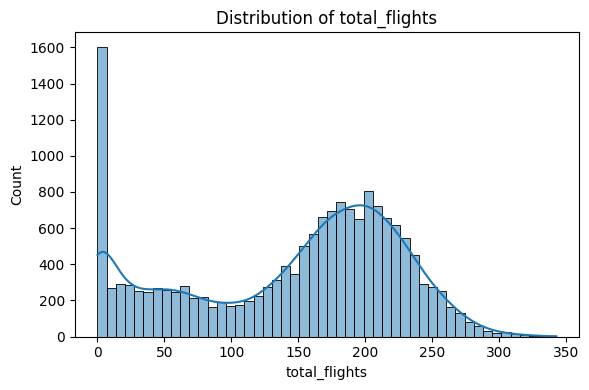

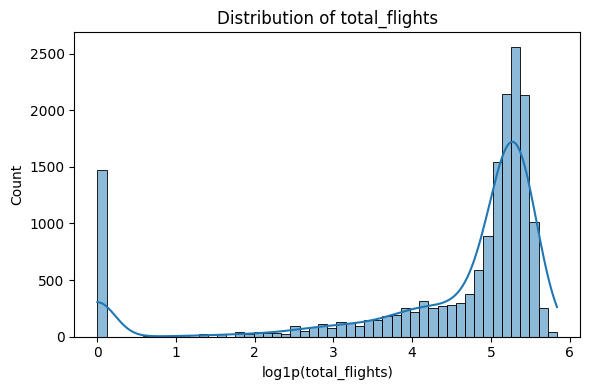

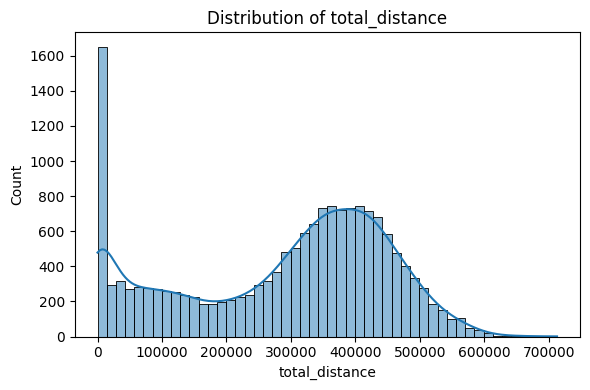

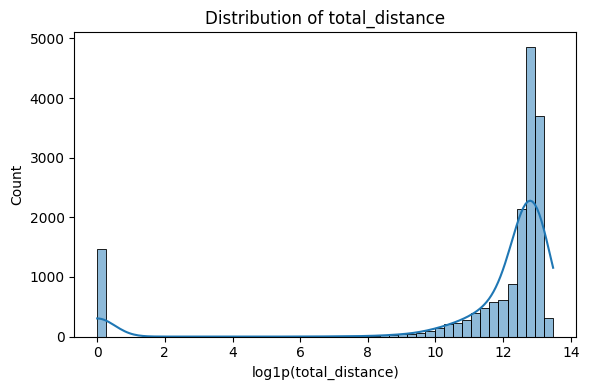

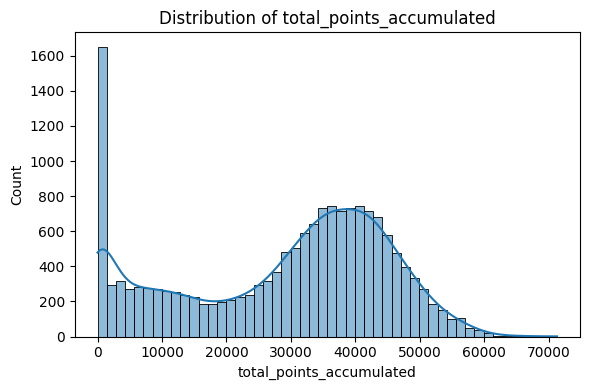

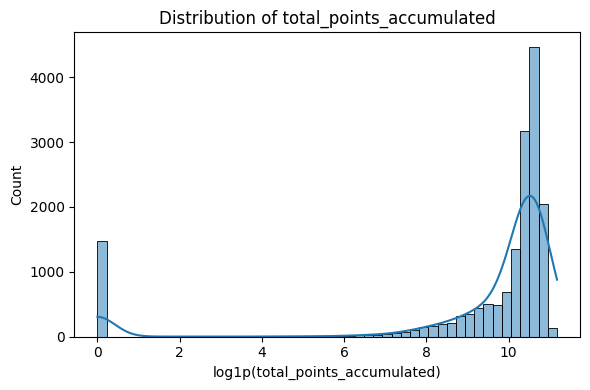

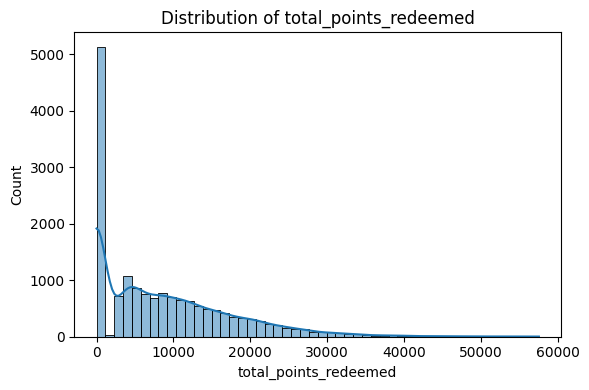

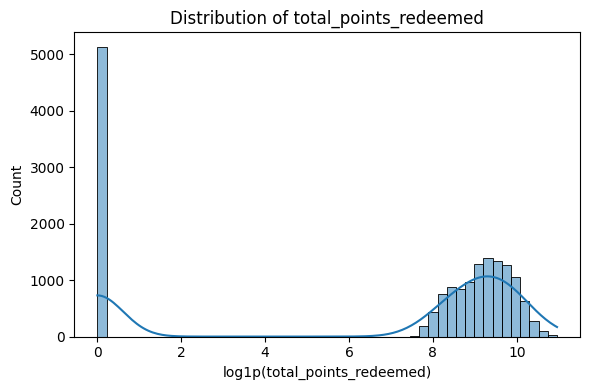

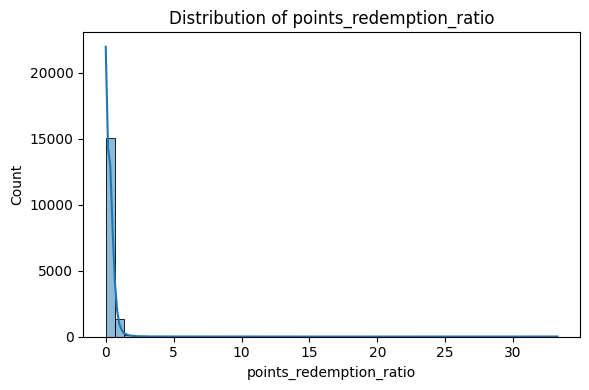

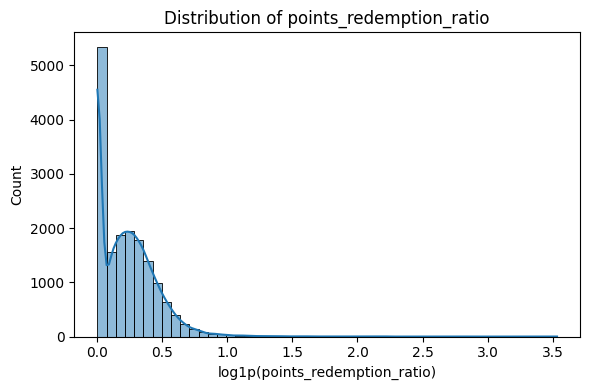

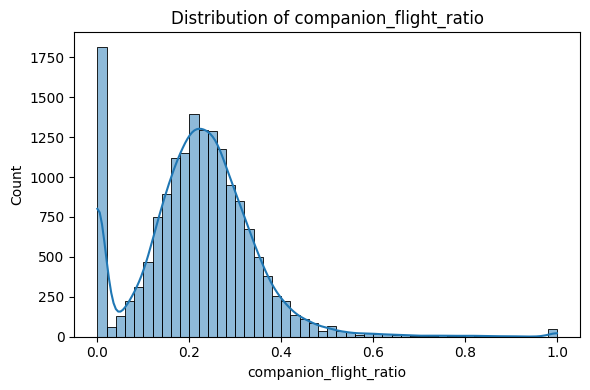

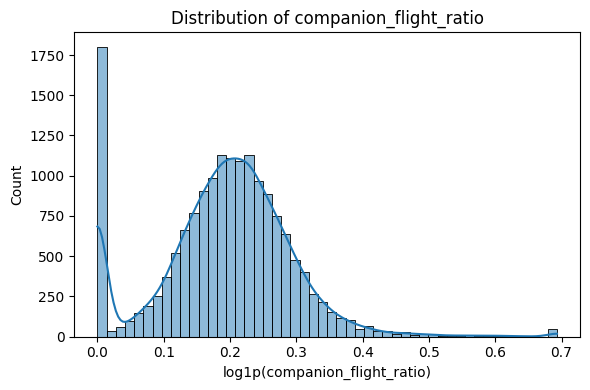

In [16]:
def plot_hist(df, col, log_scale=False, bins=50):
    plt.figure(figsize=(6,4))
    data = df[col].dropna()
    if log_scale:
        sns.histplot(np.log1p(data), bins=bins, kde=True)
        plt.xlabel(f"log1p({col})")
    else:
        sns.histplot(data, bins=bins, kde=True)
        plt.xlabel(col)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

  # Univariate distributions: original features
for col in ['total_flights', 'total_distance', 'total_points_accumulated', 'total_points_redeemed']:
    plot_hist(df, col, log_scale=False)
    plot_hist(df, col, log_scale=True)

# For ratio / rate features
for col in ['points_redemption_ratio', 'companion_flight_ratio']:
    plot_hist(df, col, log_scale=False)
    plot_hist(df, col, log_scale=True)

In [17]:
# Copy df so as not to mutate original
df2 = df.copy()

In [18]:
#Normalize by “active period”  how many months they have been active
#Define “active span” in months
df2['EnrollmentDateOpening'] = pd.to_datetime(df2['EnrollmentDateOpening'])
df2['EndDate'] = pd.to_datetime(df2['EndDate'])
# If EndDate is null for active customers, you may fill with the latest flight date
latest_date = flights['YearMonthDate'].max()
df2['EndDate_filled'] = df2['EndDate'].fillna(latest_date)
df2['ActiveDays'] = (df2['EndDate_filled'] - df2['EnrollmentDateOpening']).dt.days
df2['ActiveMonths'] = df2['ActiveDays'] / 30.0

#Flights per month (normalized)
df2['FlightsPerMonth_norm'] = df2['total_flights'] / df2['ActiveMonths'].replace(0, np.nan)

#Distance per flight
df2['AvgDistancePerFlight'] = df2['total_distance'] / df2['total_flights'].replace(0, np.nan)

#Redeem behavior relative to accumulation
df2['RedeemPerFlight'] = df2['total_points_redeemed'] / df2['total_flights'].replace(0, np.nan)
df2['AccumulatePerFlight'] = df2['total_points_accumulated'] / df2['total_flights'].replace(0, np.nan)

# 5. Companion behavior interactions
df2['DistanceTimesCompanionRatio'] = df2['total_distance'] * df2['companion_flight_ratio']

# 6. Variation / consistency features
cust_month = flights.groupby(['Loyalty#','Year','Month']).size().reset_index(name='cnt')
cust_month['year_month'] = pd.to_datetime(cust_month[['Year','Month']].assign(day=1))
pivot = cust_month.pivot(index='Loyalty#', columns='year_month', values='cnt').fillna(0)

# Compute std, max, coefficient of variation
pivot_stats = pd.DataFrame({
    'FlightCountStd': pivot.std(axis=1),
    'FlightCountMean': pivot.mean(axis=1),
    'FlightCountMax': pivot.max(axis=1),
})
pivot_stats['CoefVar'] = pivot_stats['FlightCountStd'] / (pivot_stats['FlightCountMean'].replace(0, np.nan))
pivot_stats = pivot_stats.reset_index().rename(columns={'Loyalty#':'Loyalty#'})

# Merge back
df2 = df2.merge(pivot_stats, on='Loyalty#', how='left')


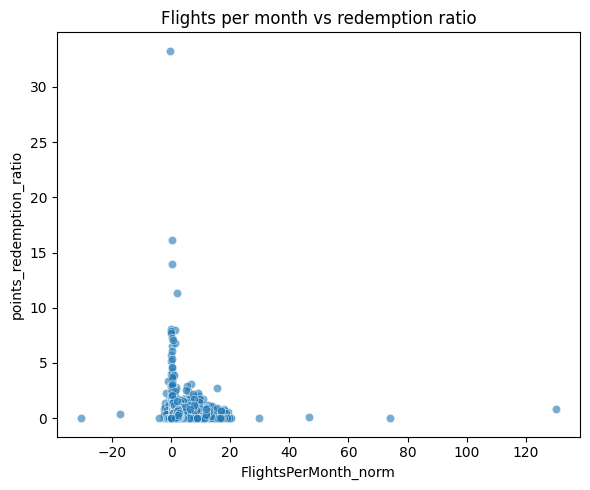

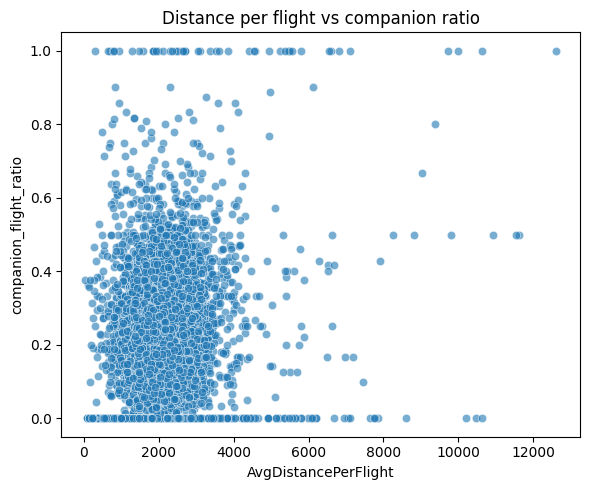

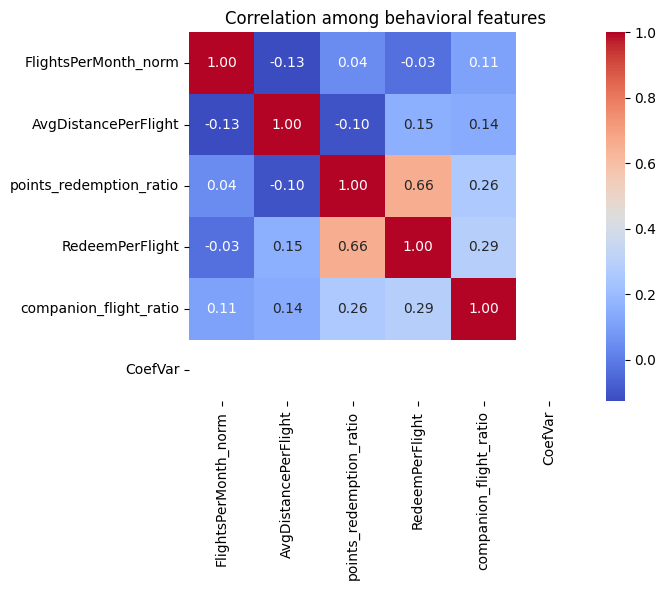

In [19]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df2, x='FlightsPerMonth_norm', y='points_redemption_ratio', alpha=0.6)
plt.title("Flights per month vs redemption ratio")
plt.tight_layout()
plt.show()

#AvgDistancePerFlight vs companion ratio
plt.figure(figsize=(6,5))
sns.scatterplot(data=df2, x='AvgDistancePerFlight', y='companion_flight_ratio', alpha=0.6)
plt.title("Distance per flight vs companion ratio")
plt.tight_layout()
plt.show()

# Correlation heatmap across engineered features
feat_cols = ['FlightsPerMonth_norm','AvgDistancePerFlight','points_redemption_ratio',
             'RedeemPerFlight', 'companion_flight_ratio', 'CoefVar']
corrmat = df2[feat_cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corrmat, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation among behavioral features")
plt.tight_layout()
plt.show()

C:\Users\Esra\AppData\Local\Temp\ipykernel_3060\3472761690.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly.index, y=monthly.values, palette="viridis")


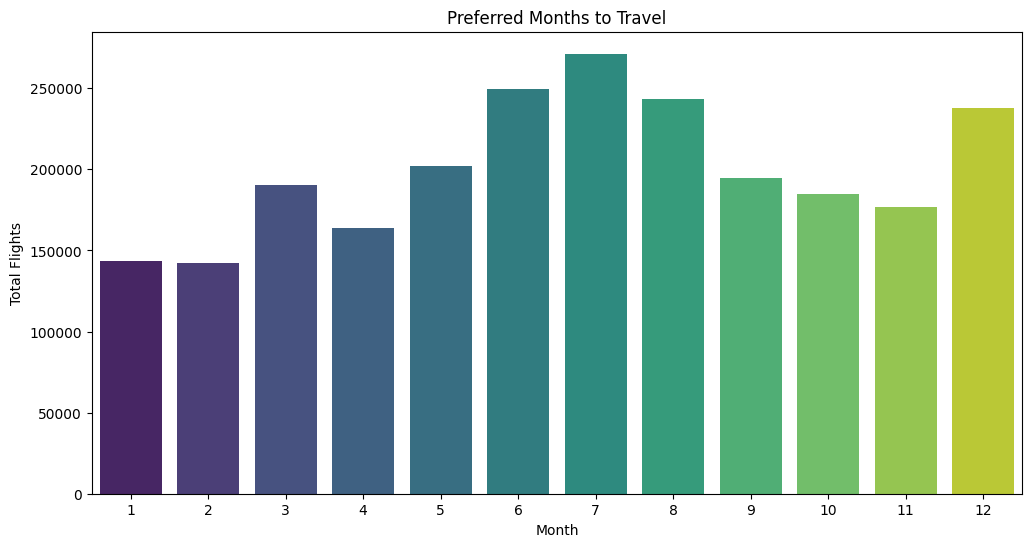

In [23]:
monthly = flights.groupby('Month')['NumFlights'].sum().reindex(range(1,13))

plt.figure(figsize=(12,6))
sns.barplot(x=monthly.index, y=monthly.values, palette="viridis")
plt.title("Preferred Months to Travel")
plt.xlabel("Month")
plt.ylabel("Total Flights")
plt.show()

C:\Users\Esra\AppData\Local\Temp\ipykernel_3060\2925348038.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasonal.index, y=seasonal.values, palette="coolwarm")


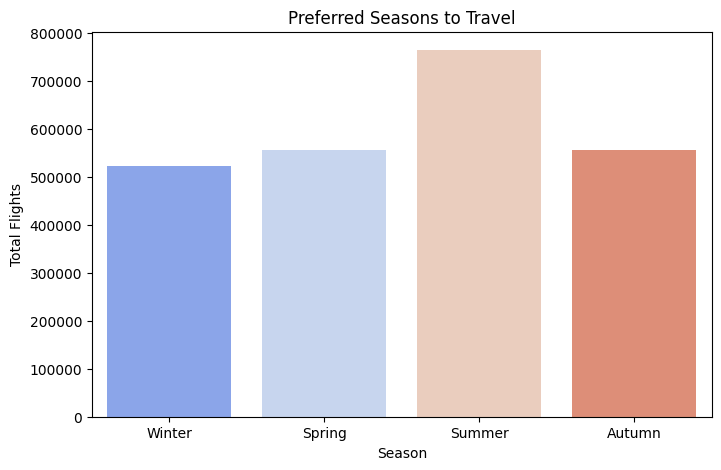

In [24]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

flights['Season'] = flights['Month'].apply(get_season)
seasonal = flights.groupby('Season')['NumFlights'].sum().reindex(['Winter','Spring','Summer','Autumn'])

plt.figure(figsize=(8,5))
sns.barplot(x=seasonal.index, y=seasonal.values, palette="coolwarm")
plt.title("Preferred Seasons to Travel")
plt.xlabel("Season")
plt.ylabel("Total Flights")
plt.show()

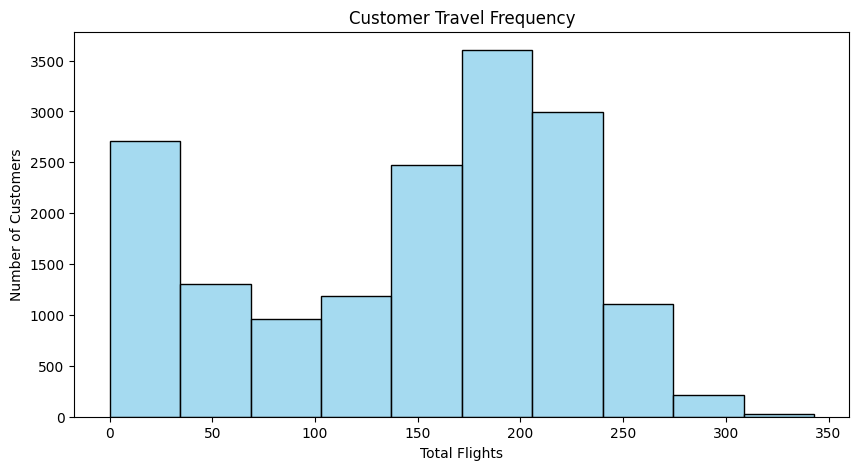

In [25]:
plt.figure(figsize=(10,5))
sns.histplot(customers['total_flights'], bins=10, kde=False, color='skyblue')
plt.title("Customer Travel Frequency")
plt.xlabel("Total Flights")
plt.ylabel("Number of Customers")
plt.show()

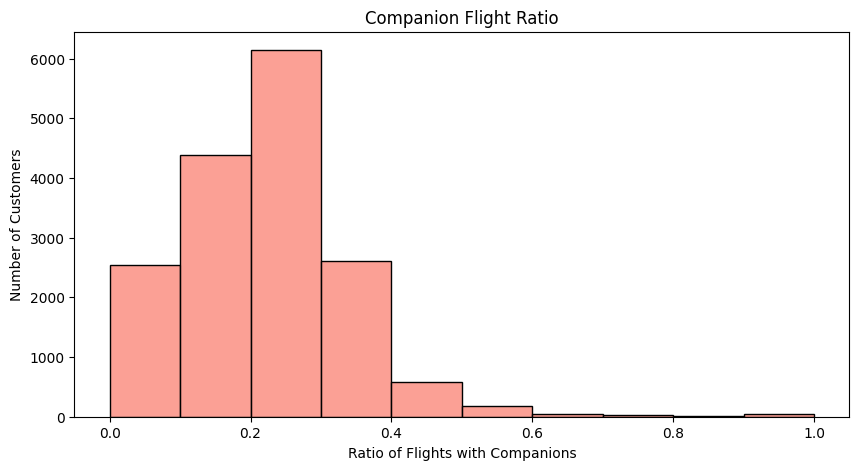

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(customers['companion_flight_ratio'], bins=10, kde=False, color='salmon')
plt.title("Companion Flight Ratio")
plt.xlabel("Ratio of Flights with Companions")
plt.ylabel("Number of Customers")
plt.show()

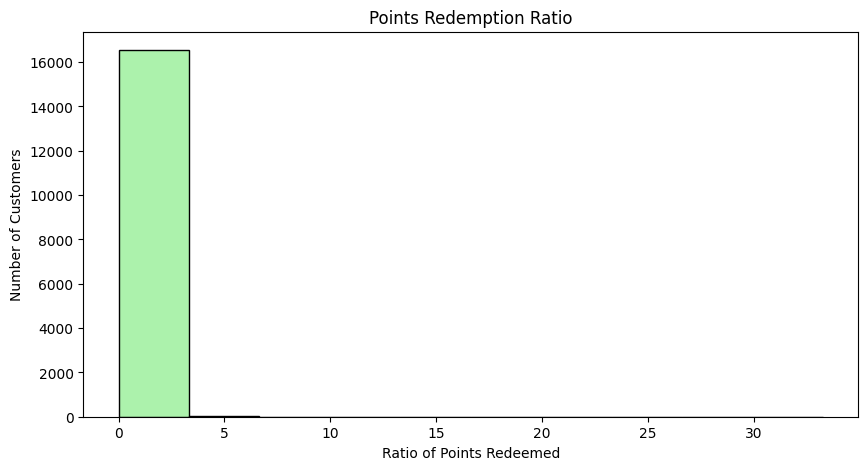

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(customers['points_redemption_ratio'], bins=10, kde=False, color='lightgreen')
plt.title("Points Redemption Ratio")
plt.xlabel("Ratio of Points Redeemed")
plt.ylabel("Number of Customers")
plt.show()

C:\Users\Esra\AppData\Local\Temp\ipykernel_3060\2981867000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='LoyaltyStatus', data=customers, palette='coolwarm')


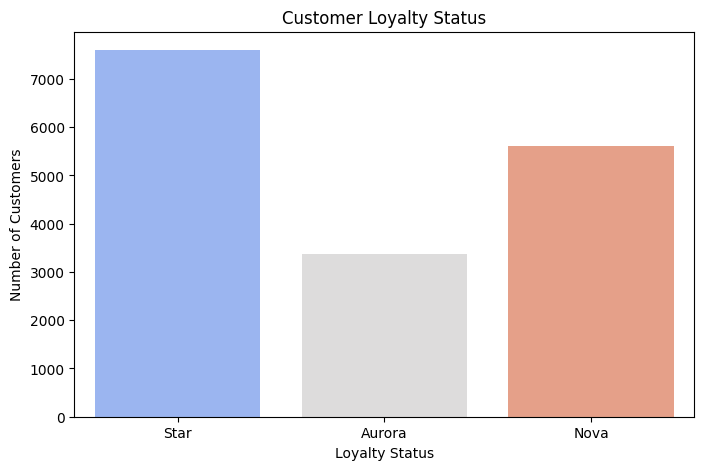

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(x='LoyaltyStatus', data=customers, palette='coolwarm')
plt.title("Customer Loyalty Status")
plt.xlabel("Loyalty Status")
plt.ylabel("Number of Customers")
plt.show()

C:\Users\Esra\AppData\Local\Temp\ipykernel_3060\1633582618.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=travel_types, y=avg_ratios, palette=['skyblue','salmon'])


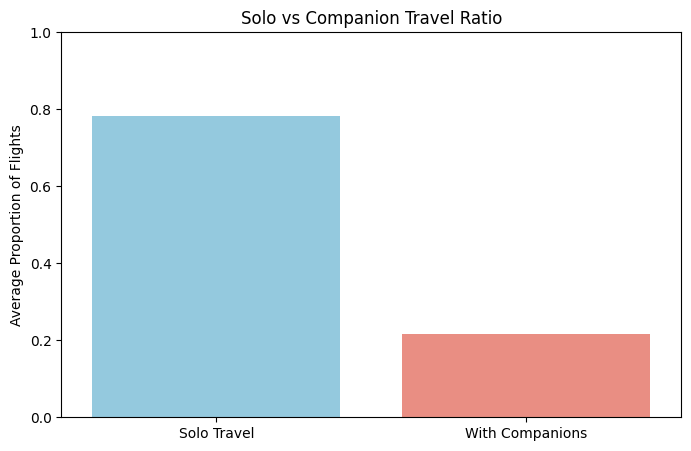

In [30]:
customers['SoloTravel'] = 1 - customers['companion_flight_ratio']

# --- Visualization: Solo vs Companion Travel ---
plt.figure(figsize=(8,5))

# Create two categories
travel_types = ['Solo Travel', 'With Companions']
# Average ratio across all customers
avg_ratios = [customers['SoloTravel'].mean(), customers['companion_flight_ratio'].mean()]

sns.barplot(x=travel_types, y=avg_ratios, palette=['skyblue','salmon'])
plt.ylabel("Average Proportion of Flights")
plt.title("Solo vs Companion Travel Ratio")
plt.ylim(0,1)
plt.show()